In [19]:
!pip install sentence-transformers scikit-learn seaborn matplotlib --quiet

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('All libraries imported successfully.')

All libraries imported successfully.


In [21]:
sentences = [
    # ── Cricket (4 sentences) ─────────────────────────────────
    "The batsman hit a magnificent six over the mid-wicket boundary.",
    "India won the Test match by an innings and 50 runs.",
    "The bowler delivered a sharp yorker that clean-bowled the opener.",
    "A dropped catch in the slips proved costly for the fielding side.",
    # ── Cooking (3 sentences) ─────────────────────────────────
    "Sauté the onions in olive oil until they turn golden brown.",
    "Marinating the chicken overnight gives it a deeper, richer flavour.",
    "Fold the egg whites gently to keep the soufflé light and airy.",
    # ── Cybersecurity (3 sentences) ───────────────────────────
    "The ransomware encrypted all files on the corporate network within minutes.",
    "Multi-factor authentication significantly reduces the risk of account takeover.",
    "Penetration testers simulate real-world attacks to expose system vulnerabilities.",
]

topic_labels = (
    ['Cricket'] * 4 + ['Cooking'] * 3 + ['Cybersecurity'] * 3
)

for i, (s, t) in enumerate(zip(sentences, topic_labels)):
    print(f"  [{i}] [{t}] {s}")

  [0] [Cricket] The batsman hit a magnificent six over the mid-wicket boundary.
  [1] [Cricket] India won the Test match by an innings and 50 runs.
  [2] [Cricket] The bowler delivered a sharp yorker that clean-bowled the opener.
  [3] [Cricket] A dropped catch in the slips proved costly for the fielding side.
  [4] [Cooking] Sauté the onions in olive oil until they turn golden brown.
  [5] [Cooking] Marinating the chicken overnight gives it a deeper, richer flavour.
  [6] [Cooking] Fold the egg whites gently to keep the soufflé light and airy.
  [7] [Cybersecurity] The ransomware encrypted all files on the corporate network within minutes.
  [8] [Cybersecurity] Multi-factor authentication significantly reduces the risk of account takeover.
  [9] [Cybersecurity] Penetration testers simulate real-world attacks to expose system vulnerabilities.


In [22]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(sentences, show_progress_bar=True)

print(f"\nEmbedding matrix shape: {embeddings.shape}")
print("Each sentence is represented as a 384-dimensional vector.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embedding matrix shape: (10, 384)
Each sentence is represented as a 384-dimensional vector.


In [23]:
sim_matrix = cosine_similarity(embeddings)

# Print as formatted table
print("Cosine Similarity Matrix (10×10)")
print("=" * 70)
header = "     " + "".join(f"  S{i:<3}" for i in range(10))
print(header)
for i in range(10):
    row = f"S{i:<3} " + "".join(f"{sim_matrix[i][j]:6.3f}" for j in range(10))
    print(row)

Cosine Similarity Matrix (10×10)
       S0    S1    S2    S3    S4    S5    S6    S7    S8    S9  
S0    1.000 0.480 0.536 0.301 0.024 0.067 0.032 0.015 0.002 0.100
S1    0.480 1.000 0.443 0.311 0.020-0.054 0.056 0.060-0.050 0.175
S2    0.536 0.443 1.000 0.327 0.143 0.059 0.096-0.038-0.069 0.082
S3    0.301 0.311 0.327 1.000-0.042 0.039 0.091 0.006 0.064 0.083
S4    0.024 0.020 0.143-0.042 1.000 0.227 0.371 0.021-0.150 0.069
S5    0.067-0.054 0.059 0.039 0.227 1.000 0.209 0.036 0.051 0.029
S6    0.032 0.056 0.096 0.091 0.371 0.209 1.000 0.005-0.012-0.031
S7    0.015 0.060-0.038 0.006 0.021 0.036 0.005 1.000 0.121 0.156
S8    0.002-0.050-0.069 0.064-0.150 0.051-0.012 0.121 1.000 0.110
S9    0.100 0.175 0.082 0.083 0.069 0.029-0.031 0.156 0.110 1.000


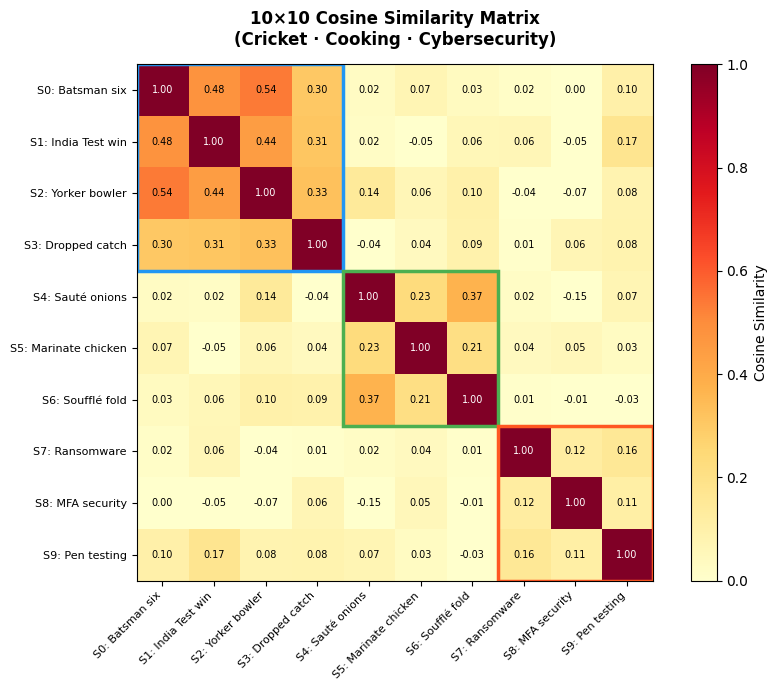

In [24]:
short_labels = [
    "S0: Batsman six",   "S1: India Test win",  "S2: Yorker bowler",
    "S3: Dropped catch", "S4: Sauté onions",    "S5: Marinate chicken",
    "S6: Soufflé fold",  "S7: Ransomware",      "S8: MFA security",
    "S9: Pen testing",
]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_labels, fontsize=8)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black' if sim_matrix[i,j] < 0.6 else 'white')
ax.set_title('10×10 Cosine Similarity Matrix\n(Cricket · Cooking · Cybersecurity)',
             fontsize=12, fontweight='bold', pad=14)
# Draw coloured boxes around each topic cluster
for start, end, color in [(0,3,'#2196F3'),(4,6,'#4CAF50'),(7,9,'#FF5722')]:
    rect = plt.Rectangle((start-0.5, start-0.5), end-start+1, end-start+1,
                          linewidth=2.5, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
plt.tight_layout()
plt.show()

In [25]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

query_sims = cosine_similarity(query_embedding, embeddings)[0]
top2_indices = np.argsort(query_sims)[::-1][:2]

print(f'Query: "{query}"')
print("-" * 60)
print("Top 2 Most Similar Sentences:\n")
for rank, idx in enumerate(top2_indices, 1):
    print(f"  Rank {rank}: [{idx}] [{topic_labels[idx]}]")
    print(f'    "{sentences[idx]}"')
    print(f"    Cosine Similarity Score: {query_sims[idx]:.4f}\n")

print("Observation: Both top results belong to the 'Cricket' topic,")
print("confirming that the model captures semantic meaning correctly.")

Query: "The bowler took three wickets in one over"
------------------------------------------------------------
Top 2 Most Similar Sentences:

  Rank 1: [2] [Cricket]
    "The bowler delivered a sharp yorker that clean-bowled the opener."
    Cosine Similarity Score: 0.6320

  Rank 2: [0] [Cricket]
    "The batsman hit a magnificent six over the mid-wicket boundary."
    Cosine Similarity Score: 0.6024

Observation: Both top results belong to the 'Cricket' topic,
confirming that the model captures semantic meaning correctly.
